In [1]:
import numpy as np
import pandas as pd

np.random.seed(23) 

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

#df = df.append(df1,ignore_index=True)
#df = df.sample(40)

df = pd.concat([df, df1], ignore_index=True)

df = df.sample(40, random_state=23)

# we create here dataframe with 40 rows and 4 columns 

In [2]:
df.shape

(40, 4)

In [3]:
df.head()

# Now, we just want to change this data from 3-D -> 2-D

,feature1,feature2,feature3,target
18,-0.331617,-1.632386,0.619114,1
23,1.010229,1.437830,2.327788,0
8,0.241106,-0.952510,-0.136267,1
22,1.676860,4.187503,-0.080565,0
33,2.823378,-0.332863,2.637391,0


In [4]:
import sys        
!{sys.executable} -m pip install plotly    

In [5]:
import plotly
print("Plotly version:", plotly.__version__)

Plotly version: 6.3.0


In [6]:
import plotly
print("Plotly version:", plotly.__version__)

Plotly version: 6.3.0


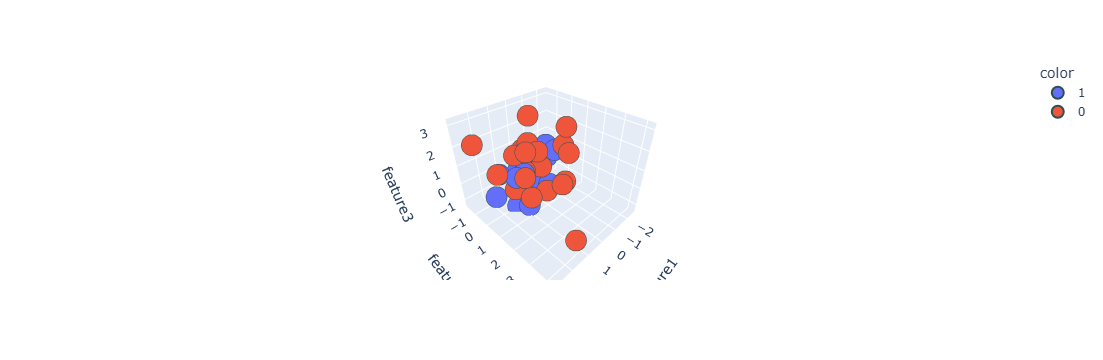

In [7]:
import plotly.express as px
     
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'], 
                       color = df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,line=dict(width=2, color='DarkSlateGrey')),    
                       selector=dict(mode='markers'))  

fig.show()

# this shows that how the datapoints are arranged in 3-D
# Now,Our end goal is that we have to find best possible 2 axes in 2-D, so that using this we can represent this data in 2-D system

In [8]:
# first step:- 'Mean Centering' 

# Apply Standard scaling 

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])  # we form scaling on all 3 columns

In [9]:
# second step:- find 'Covarience Matrix'

covarience_matrix = np.cov([df.iloc[:,0], df.iloc[:,1], df.iloc[:,2]]) # we provided here our all 3 columns for finding covarience
print("Covarience matrix:\n", covarience_matrix)     

# we can check here that all diagonal elements are equal(i.e., variances)
# And, others are symmetric to each other(i.e, covariences ) 

Covarience matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [10]:
# third step:-  finding 'Eigenvectors and its Eigenvalues'

eigen_values, eigen_vectors = np.linalg.eig(covarience_matrix)   # "np.linalg.eig()" is the function of 'linear algebra' 
print("Eigenvalues:\n", eigen_values)
print("\nEigenvectors:\n", eigen_vectors)

# if we are working on 3-D, then, we will get 3 eigenvalues and 3 eigenvectors

Eigenvalues:
 [1.3536065  0.94557084 0.77774573]

Eigenvectors:
 [[-0.53875915 -0.69363291  0.47813384]
 [-0.65608325 -0.01057596 -0.75461442]
 [-0.52848211  0.72025103  0.44938304]]


%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


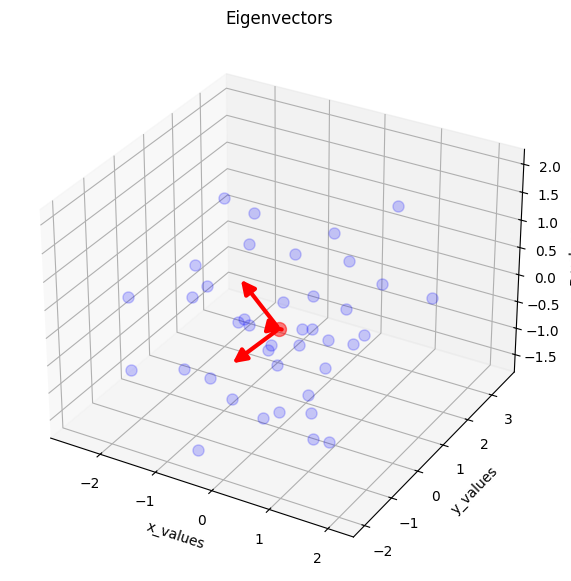

In [11]:
%pylab inline

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D, proj3d
from matplotlib.patches import FancyArrowPatch
import numpy as np

class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer): 
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, ax.get_proj())  # ✅
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, ax.get_proj())  # ✅
        return np.min(zs)

# ----------------------------
# Example usage
# ----------------------------
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

# scatter points
ax.plot(df['feature1'], df['feature2'], df['feature3'], 'o',
        markersize=8, color='blue', alpha=0.2)

# centroid
mean_x, mean_y, mean_z = df['feature1'].mean(), df['feature2'].mean(), df['feature3'].mean()
ax.plot([mean_x], [mean_y], [mean_z], 'o', markersize=10, color='red', alpha=0.5)

# eigenvectors
for v in eigen_vectors.T:
    a = Arrow3D([mean_x, mean_x+v[0]], 
                [mean_y, mean_y+v[1]], 
                [mean_z, mean_z+v[2]], 
                mutation_scale=20, lw=3, arrowstyle="-|>", color="r")
    ax.add_artist(a)

ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')
plt.title('Eigenvectors')
plt.show()


# in this, we plot all that 3 vectors in the space
# so, from that, we choose top 2 eigenvectors, which have the highest eigenvalues.

In [12]:
pc = eigen_vectors[0:2]   # we take here top-2 eigenvectors
pc                        # we called it 'pc' --> "principal component"

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [13]:
# Now, jo hmare 40 rows hai hmare pass, un sbko hme in nye 2-D system mein shift krna hai
# so, phle hmare data ka shape (40,3) tha,so after that, it becomes (40,2) (b/c ab hm isko 2-D system mein leke aa rhe hai)

transformed_df = np.dot(df.iloc[:,0:3], pc.T)                   # so, we calculate here projection i.e., X.U^T (T = transpose)
# 40,3 - 3,2  --> 40,2 (shape of our new data)
new_df = pd.DataFrame(transformed_df, columns=['PC1', 'PC2'])   # we created here a new dataframe
new_df['target'] = df['target'].values                          # we add here the target row on this data
new_df.head()

,PC1,PC2,target
0,1.726114,0.492511,1
1,-0.220797,-1.441911,0
2,0.688605,0.658084,1
3,-3.367715,-0.254627,0
4,0.227326,-2.669841,0


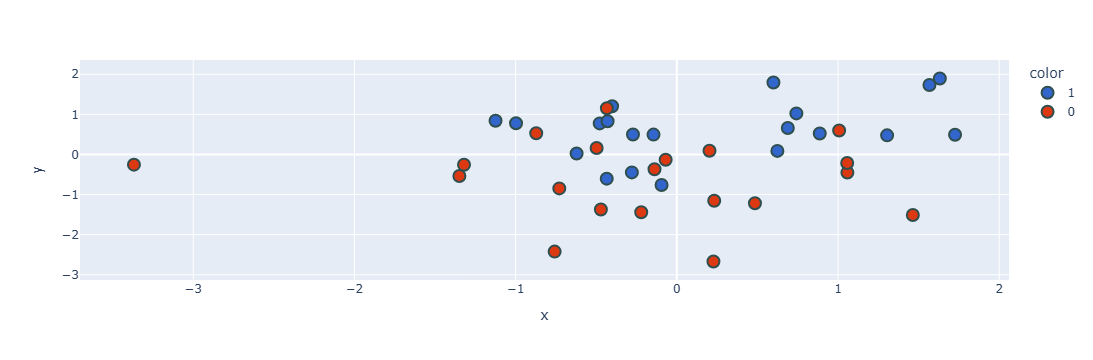

In [14]:
# for plotting this 2-D data in 2-D coordinate system

new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()

# So, this is our final data
# we change our dataset from 3-D -> 2-D